# Comprehensive Sales Data Analysis and Visualization using Python

## Objective
To analyze sales data using NumPy for numerical operations, Pandas for data handling, and Matplotlib for visualization to generate meaningful insights.

### Import Libraries

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

### Load Dataset

In [75]:
df=pd.read_csv("Sales_dataset.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Create Missing & Duplicate Values

In [76]:
#create missing values
df.loc[0, 'Sales'] = None
df.loc[5, 'Region'] = None
#duplicate 1st 5 rows
df = pd.concat([df, df.iloc[:5]], ignore_index=True)
print("Total missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Total missing values: 3
Duplicate rows: 5


## Part 1: Numpy Operation

#### Convert the Sales column into a NumPy array.

In [90]:
Sales_array=np.array(df['Sales'].dropna())
print("Sales Array:",Sales_array)

Sales Array: [229.93552124 731.94        14.62       ... 258.576       29.6
 243.16      ]


#### Calculate: Mean, Median, Standard deviation

In [91]:
mean_value=np.mean(Sales_array)
median_value=np.median(Sales_array)
std_value=np.std(Sales_array)

print("Mean:",mean_value)
print("Median:",median_value)
print("Standard Deviation:",std_value)

Mean: 229.85479645999965
Median: 54.489999999999995
Standard Deviation: 623.2138360283044


#### Normalize the sales data(scale values between 0 and 1).

In [7]:
mn=np.min(Sales_array)
mx=np.max(Sales_array)
normalized_sales=(Sales_array-mn)/(mx-mn)
print(normalized_sales)

[0.01155206 0.0323127  0.0006262  ... 0.01140258 0.00128792 0.0107216 ]


#### Find top 3 highest sales values and their indices

In [8]:
top3_indices = np.argsort(Sales_array)[-3:]
top3_values = Sales_array[top3_indices]
print("Top 3 Sales Values:", top3_values)
print("Their Indices:", top3_indices)

Top 3 Sales Values: [13999.96 17499.95 22638.48]
Their Indices: [8153 6826 2697]


#### Compare mean using NumPy vs Pandas

In [9]:
numpy_mean = np.nanmean(df['Sales'])
pandas_mean = df['Sales'].mean()
print("NumPy Mean:", numpy_mean)
print("Pandas Mean:", pandas_mean)

NumPy Mean: 229.85800083049833
Pandas Mean: 229.85800083049833


##### Difference between Numpy and Pandas

NumPy and Pandas both compute the mean, but Pandas automatically ignores missing values, while NumPy requires functions like nanmean() to handle them. Pandas is more convenient for structured data, whereas NumPy is faster for numerical computations.

## Part 2: Data Loading and Inspection(Pandas)

#### Load dataset using Pandas

In [92]:
df=pd.read_csv("Sales_dataset.csv")

#### Display 1st 5 rows and last 5 rows

In [102]:
print("\n===== FIRST 5 ROWS =====\n")
print(df.head())
print("\n===== LAST 5 ROWS =====\n")
print(df.tail())


===== FIRST 5 ROWS =====

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Categ

#### Show info() and describe()

In [96]:
print("\n===== DATASET INFO =====\n")
df.info()
print("\n===== STATISTICAL SUMMARY =====\n")
print(df.describe())


===== DATASET INFO =====

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-n

## Part 3: Data Cleaning

#### Convert Date to datetime format

In [77]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

#### Handle missing values: Sales→fill with mean, Product/Region→fill with "Unknown"

In [100]:
df['Sales'] = df['Sales'].fillna(df['Sales'].mean())
df['Product Name'] = df['Product Name'].fillna("Unknown")
df['Region'] = df['Region'].fillna("Unknown")

print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


#### Remove duplicate rows

In [101]:
df.drop_duplicates(inplace=True)
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## Part 4: Data Analysis

#### Calculate total sales

In [17]:
total_sales = df['Sales'].sum()
print("Total Sales:", total_sales)

Total Sales: 2297168.8358212365


#### Calculate Sales by Product

In [46]:
sales_by_product = df.groupby('Product Name')['Sales'].sum()
print("Sales by Product:\n", sales_by_product)

Sales by Product:
 Product Name
"While you Were Out" Message Book, One Form per Page                                                     25.228
#10 Gummed Flap White Envelopes, 100/Box                                                                 41.300
#10 Self-Seal White Envelopes                                                                           108.682
#10 White Business Envelopes,4 1/8 x 9 1/2                                                              488.904
#10- 4 1/8" x 9 1/2" Recycled Envelopes                                                                 286.672
                                                                                                         ...   
iKross Bluetooth Portable Keyboard + Cell Phone Stand Holder + Brush for Apple iPhone 5S 5C 5, 4S 4     477.660
iOttie HLCRIO102 Car Mount                                                                              215.892
iOttie XL Car Mount                                                     

#### Calculate Sales by Region

In [35]:
sales_by_region = df.groupby('Region')['Sales'].sum()
print("\nSales by Region:\n", sales_by_region)


Sales by Region:
 Region
Central    501239.890800
East       678781.240000
South      391689.880521
Unknown        48.860000
West       725408.964500
Name: Sales, dtype: float64


#### Identify Best Selling Product

In [36]:
best_product = sales_by_product.idxmax()
print("Best Selling Product:", best_product)

Best Selling Product: Canon imageCLASS 2200 Advanced Copier


#### Identify Lowest Selling Product

In [37]:
lowest_region = sales_by_region.idxmin()
print("Lowest Performing Region:", lowest_region)

Lowest Performing Region: Unknown


#### Calculate Average Sales Per Product

In [38]:
avg_sales_product = df.groupby('Product Name')['Sales'].mean()
print("Average Sales per Product:\n", avg_sales_product)

Average Sales per Product:
 Product Name
"While you Were Out" Message Book, One Form per Page                                                     8.409333
#10 Gummed Flap White Envelopes, 100/Box                                                                10.325000
#10 Self-Seal White Envelopes                                                                           27.170500
#10 White Business Envelopes,4 1/8 x 9 1/2                                                              69.843429
#10- 4 1/8" x 9 1/2" Recycled Envelopes                                                                 28.667200
                                                                                                          ...    
iKross Bluetooth Portable Keyboard + Cell Phone Stand Holder + Brush for Apple iPhone 5S 5C 5, 4S 4     95.532000
iOttie HLCRIO102 Car Mount                                                                              43.178400
iOttie XL Car Mount                            

## Part 5: Visualization(Matplotlib)

#### Sales by Product Graph

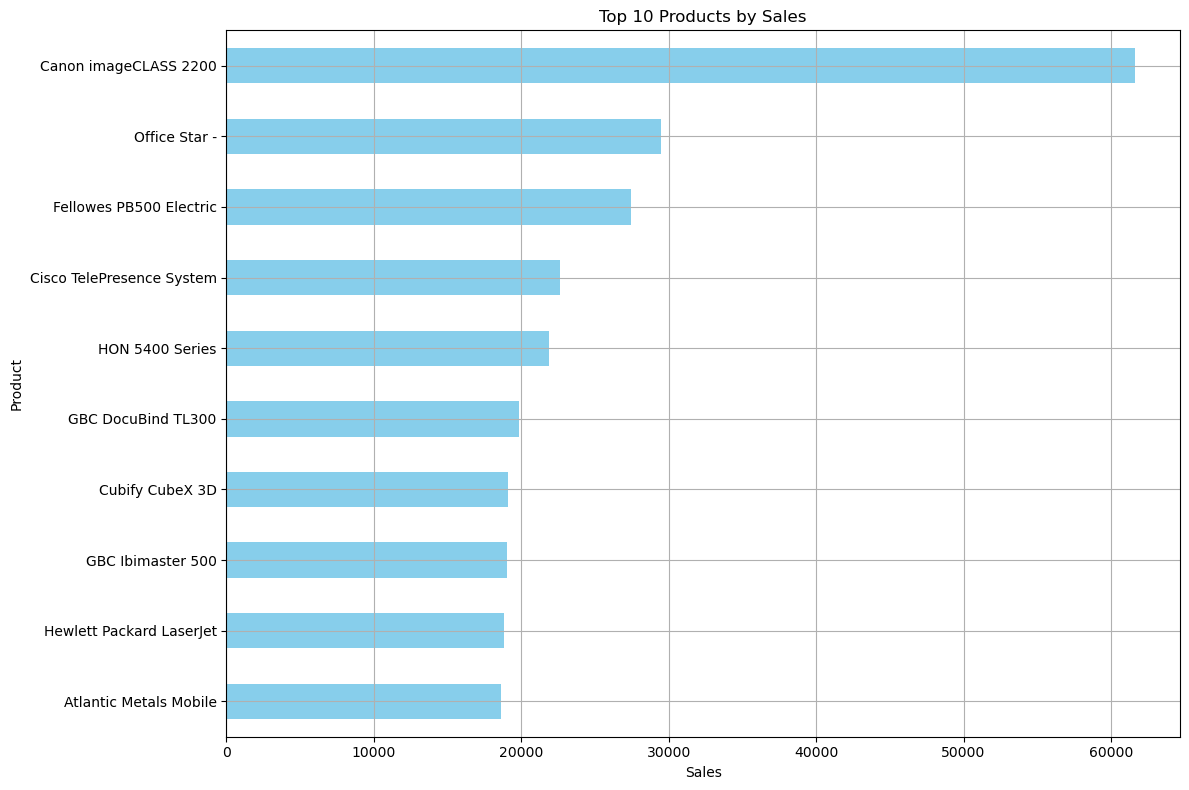

In [79]:
df['Short_Product']=df['Product Name'].str.split().str[:3].str.join(' ')

top_products=df.groupby('Short_Product')['Sales'].sum().nlargest(10)

plt.figure(figsize=(12,8))
top_products.sort_values().plot(kind='barh',color='skyblue')

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.grid(True)
plt.tight_layout()
plt.savefig("sales_by_product.png")
plt.show()

#### Sales by Region Graph

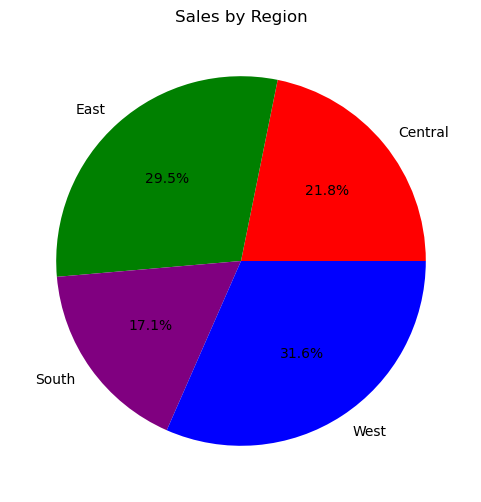

In [80]:
plt.figure(figsize=(6,6))
regions=sales_by_region.index
color_map={
    'Central':'red',
    'West':'blue',
    'East':'green',
    'South':'purple',
    'Unknown':'orange'
}
colors=[color_map[region] for region in regions]
plt.pie(sales_by_region,
        labels=regions,
        autopct='%1.1f%%',
        colors=colors)
plt.title("Sales by Region")
plt.savefig("sales_by_region.png")
plt.show()

#### Sales over Time Graph

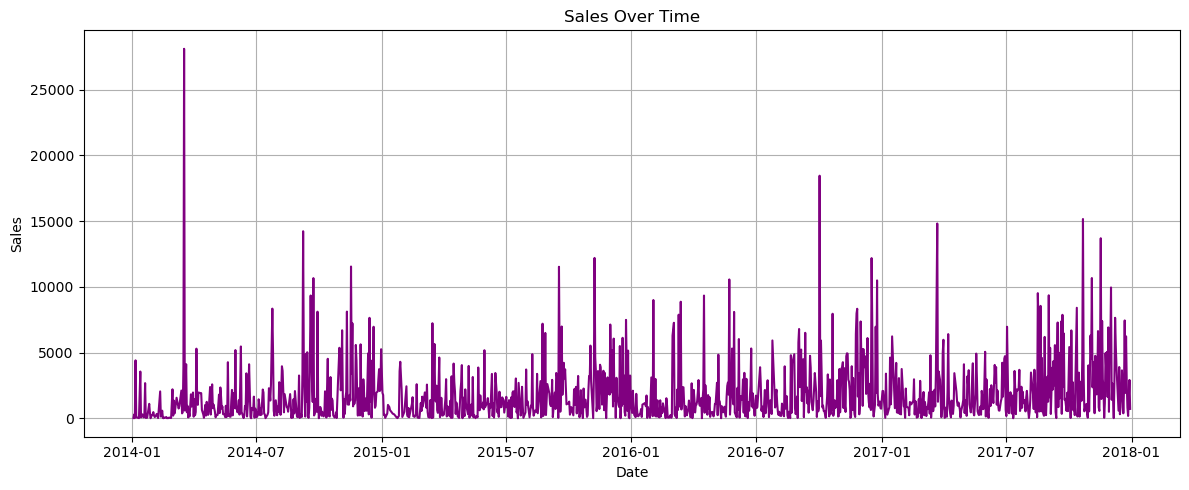

In [82]:
sales_over_time = df.groupby('Order Date')['Sales'].sum()
plt.figure(figsize=(12,5))
plt.plot(sales_over_time.index,sales_over_time.values,color='purple')

plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)
plt.tight_layout()
plt.savefig("sales_over_time.png")
plt.show()

#### Combine 2 Graphs in one figure

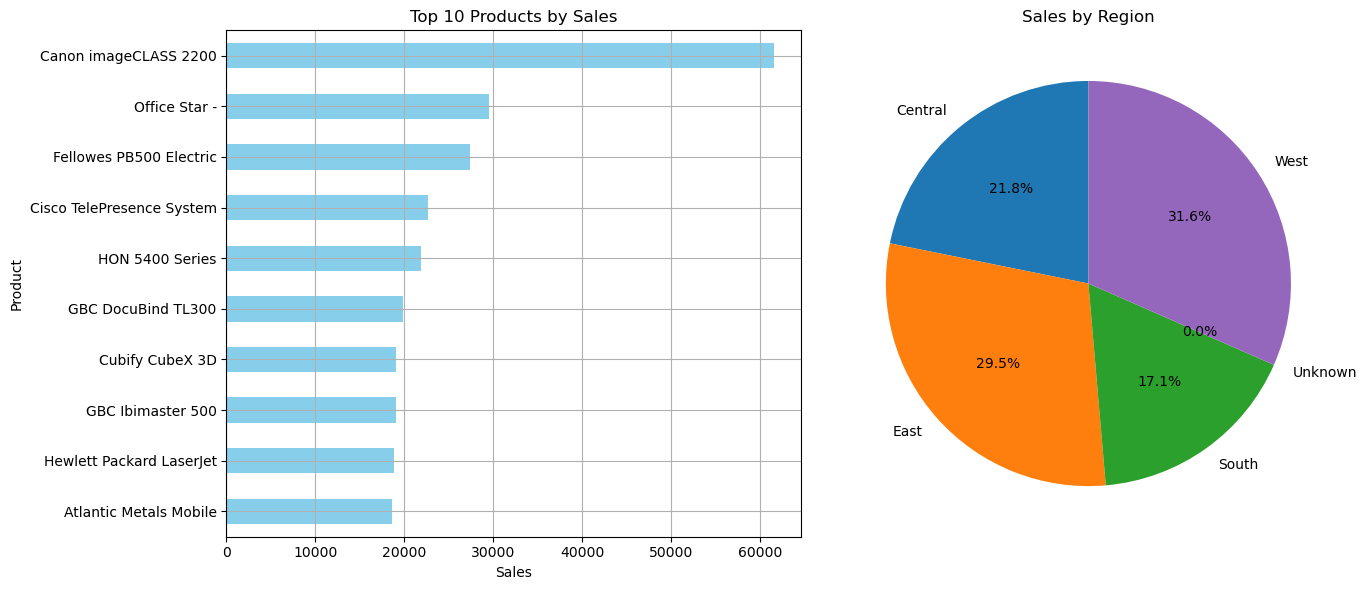

In [83]:
fig, axes=plt.subplots(1, 2, figsize=(14,6))
top_products=df.groupby('Short_Product')['Sales'].sum().nlargest(10)
top_products.sort_values().plot(kind='barh',ax=axes[0],color='skyblue')

axes[0].set_title("Top 10 Products by Sales")
axes[0].set_xlabel("Sales")
axes[0].set_ylabel("Product")
axes[0].grid(True)

sales_by_region = df.groupby('Region')['Sales'].sum()

axes[1].pie(sales_by_region,
            labels=sales_by_region.index,
            autopct='%1.1f%%',
            startangle=90)

axes[1].set_title("Sales by Region")

plt.tight_layout()
plt.savefig("combined_charts.png", dpi=300, bbox_inches='tight')
plt.show()

## Part 6: Time-Based Analysis

#### Extraction Month,Day from Dataset

In [84]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Month']=df['Order Date'].dt.month
df['Day']=df['Order Date'].dt.day

#### Calculation Monthly Sales from Dataset

In [85]:
monthly_sales=df.groupby('Month')['Sales'].sum()
print("Monthly Sales:\n",monthly_sales)

Monthly Sales:
 Month
1      94924.835600
2      59751.251400
3     205005.488800
4     137762.128600
5     155028.811700
6     152718.679300
7     147238.097000
8     159044.063000
9     307649.945700
10    200322.984700
11    352429.046521
12    325293.503500
Name: Sales, dtype: float64


#### Month with highest Sales

In [86]:
best_month=monthly_sales.idxmax()
print("Month with Highest Sales:",best_month)

Month with Highest Sales: 11


#### Monthly Sales Trend Graph using Matplotlib

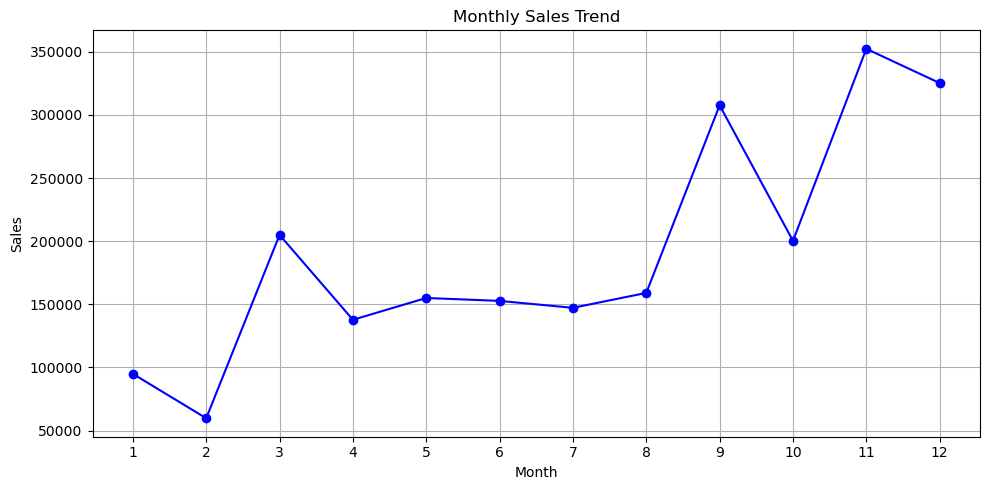

In [87]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index,monthly_sales.values,marker='o',color='blue')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)

plt.xticks(monthly_sales.index)

plt.tight_layout()
plt.savefig("monthly_sales.png", dpi=300, bbox_inches='tight')
plt.show()

## Part 7: Final Cleaned Sales Data Output

In [89]:
df.to_csv("cleaned_sales.csv", index=False)

## Conclusion
The analysis provided insights into product performance, regional sales distribution, and time-based trends. Visualization helped in identifying top-performing products and peak sales periods.